In [3]:
import jax
jax.config.update("jax_enable_x64", True)

from jax import jit, grad, jacobian, vmap, lax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt

from functools import partial
import time

In [4]:
mol = 'heh+'
basis = '6-31g'
method = 'fci'

In [5]:
dt = 0.01
T = 200.0
numsteps = int(np.ceil(T/dt))
print("numsteps = " + str(numsteps))

# field parameters: 
freq = 0.25              # frequency
amp = 0.5                # amplitude
ncyc = 5.0               # number of cycles to keep field on

# Let us take the field to be
# amp * sin(2 * pi * freq * t) so that the period is T = 1 / freq.
# Thus we will keep the field on for ncyc * T = ncyc / freq a.u.,
# which translates into ncyc / (dt * freq) time steps.

stepoff = int(np.ceil(ncyc / (dt * freq)))
print("field will be on for " + str(stepoff) + " time steps")

numsteps = 20000
field will be on for 2000 time steps


In [6]:
fname = method + '_' + mol + '_' + basis + '.npz'
print(fname)

fci_heh+_6-31g.npz


In [7]:
prefix = './psi4data/'
psi4data = np.load(prefix + fname)

In [8]:
psi4data['ham']

array([-2.93231075, -2.14209775, -1.96404284, -1.41552484, -1.35282616,
       -0.99688458, -0.6654203 , -0.57566881, -0.08763561,  0.08179299,
        0.21715018,  0.44229521,  0.69881705,  0.90207512,  1.09915501,
        1.42731566])

In [9]:
print(list(psi4data.keys()))

['C', 'S', 'AOdipmat', 'CIdimatz', 'Bten', 'ham']


In [10]:
drcCI = psi4data['Bten'].shape[0]
drc = psi4data['Bten'].shape[2]

In [11]:
# propagate starting with a particular initial condition ic
statesCI = np.zeros((drcCI, numsteps+1), dtype=np.complex128)
statesCI[0,0] = 1.0
cnt = 0

# store the propagators
# could modify this later to store only when field is on
fieldprop = np.zeros((drcCI, drcCI, numsteps), dtype=np.complex128)

# propagate solution forward in time
for j in range(numsteps):
    h = np.diag(psi4data['ham'])
    if (j < stepoff):
        field = amp * np.sin(2*np.pi*freq*j*dt)
        print("Time step j = " + str(j) + "; field strength = " + str(field)) 
        h += field * psi4data['CIdimatz']
        dd, vv = np.linalg.eigh(h)
        prop = vv @ np.diag(np.exp(-1j * dt * dd)) @ vv.conj().T
    else:
        prop = np.diag(np.exp(-1j * dt * psi4data['ham']))
    
    fieldprop[:, :, j] = prop
    statesCI[:,j+1] = prop @ statesCI[:,j]

Time step j = 0; field strength = 0.0
Time step j = 1; field strength = 0.007853658655910338
Time step j = 2; field strength = 0.015705379539064146
Time step j = 3; field strength = 0.023553225354821333
Time step j = 4; field strength = 0.03139525976465669
Time step j = 5; field strength = 0.03922954786392247
Time step j = 6; field strength = 0.04705415665925716
Time step j = 7; field strength = 0.054867155545522635
Time step j = 8; field strength = 0.06266661678215213
Time step j = 9; field strength = 0.07045061596879133
Time step j = 10; field strength = 0.07821723252011543
Time step j = 11; field strength = 0.08596455013970476
Time step j = 12; field strength = 0.09369065729286231
Time step j = 13; field strength = 0.10139364767825625
Time step j = 14; field strength = 0.10907162069827127
Time step j = 15; field strength = 0.1167226819279527
Time step j = 16; field strength = 0.1243449435824274
Time step j = 17; field strength = 0.13193652498268646
Time step j = 18; field strength =

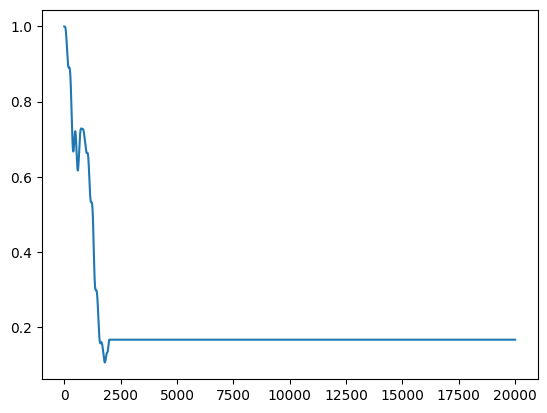

In [12]:
plt.plot(np.abs(statesCI[0,:]))
plt.show()

In [13]:
# compute and store all 1-RDMs
Bmat = psi4data['Bten'].reshape((drcCI**2, drc**2))
BmatT = Bmat.T
truerdms = np.zeros((numsteps+1, drc, drc), dtype=np.complex128)
for j in range(numsteps+1):
    a = statesCI[:, [j]]
    trueden = a @ a.conj().T
    truerdms[j, :, :] = (BmatT @ trueden.reshape((-1))).reshape((drc, drc))

In [14]:
# check at once whether all 1-RDM traces are close to 2
print( np.mean(np.abs(np.einsum('jaa->j',truerdms) - 2)) )

5.950261719783854e-13


In [15]:
# BmatT has drcCI**2 columns
# let us figure out which of these columns are actually non-trivial
colnorms = np.array( list( map( lambda j : np.linalg.norm(BmatT[:,j]), np.arange(drcCI**2, dtype=np.int16) ) ) )
goodcols = np.where(colnorms > 1e-14)[0]
badcols = np.where(colnorms <= 1e-14)[0]
diagcols = np.where(np.eye(drcCI).reshape((-1)))[0]
fincols = goodcols[~np.isin(goodcols, diagcols)]

In [16]:
zerostates = []
for j in range(drcCI):
    if np.linalg.norm(statesCI[j,:]) < 1e-10:
        zerostates.append(j)

In [17]:
print(zerostates)

[1, 3, 5, 8, 10, 13]


In [18]:
truedens = np.einsum('in,jn->ijn',statesCI,statesCI.conj())
truedenflat = truedens.reshape((drcCI**2, numsteps+1))

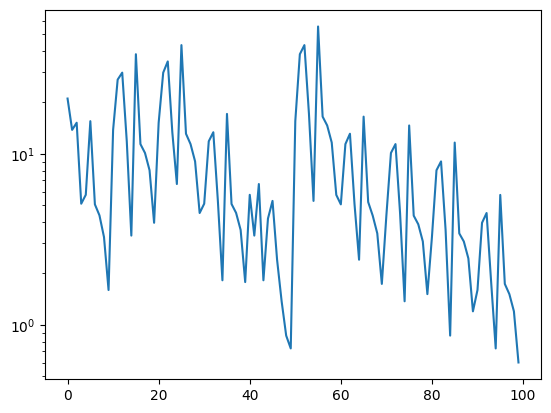

In [19]:
truedencolnorms = np.array( list( map( lambda j : np.linalg.norm(truedenflat[j,:]), np.arange(drcCI**2, dtype=np.int16) ) ) )
truedengoodcols = np.where(truedencolnorms > 1e-10)[0]
plt.semilogy(truedencolnorms[truedengoodcols])
plt.show()

In [20]:
# J = 1135
# ell = 400
# Cmat = np.eye(drcCI, drcCI)
# BtildeT = BmatT[:, truedengoodcols]
# bigmat = np.copy(BtildeT)

# for j in range(1, ell+1):
#     Cmat = Cmat @ fieldprop[:,:,J - j].conj().T
#     Amat = Cmat.conj().T
#     bigprop = np.kron( Cmat.T, Amat )
#     bigmat = np.concatenate([bigmat, (BmatT @ bigprop)[:, truedengoodcols]], axis=0)

# a = statesCI[:, [J]]
# trueden = a @ a.conj().T
# truedentilde = trueden.reshape((-1))[truedengoodcols]
# trueq = bigmat @ truedentilde
# err = 0
# for j in range(ell+1):
#     si = j*drc**2
#     ei = (j+1)*drc**2
#     err += np.linalg.norm( truerdms[:,:,J-j].reshape((-1)) - trueq[si:ei])

# print(err)
# print(np.linalg.matrix_rank(bigmat))

In [21]:
fieldpropJ = jnp.array(fieldprop)
tdgc = jnp.array(truedengoodcols, dtype=jnp.int32)
print(tdgc.shape[0])
BmatT = jnp.array(BmatT)
BtildeT = BmatT[:, truedengoodcols]
zerostatesJ = jnp.array(zerostates, dtype=jnp.int32)

ERROR:2026-05-03 16:09:50,495:jax._src.xla_bridge:477: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/data/hbhat/miniconda3/envs/jax2026/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 475, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/data/hbhat/miniconda3/envs/jax2026/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/data/hbhat/miniconda3/envs/jax2026/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


100


In [22]:
# # build right product: bigmat against reduced vec{P(t)}
# def rightprod(redvecp, J):
#     fullvecp = jnp.zeros(drcCI**2, dtype=jnp.complex128)
#     fullvecp = fullvecp.at[tdgc].set(redvecp)
#     fullp = fullvecp.reshape((drcCI, drcCI))
#     out = [ BtildeT @ redvecp ]
#     Cmat = jnp.eye(drcCI)
#     for j in range(1, ell+1):
#         Cmat = Cmat @ fieldpropJ[:,:,J - j].conj().T
#         backden = Cmat.T @ fullp @ Cmat.conj()
#         out.append( BtildeT @ backden.reshape((-1))[tdgc] )
#     return jnp.concatenate(out)

In [23]:
# # build left product: bigmat.T against vec{Q(t)}
# def leftprod(vecq, J):
#     drc2 = drc**2
#     out = []
#     Cmat = jnp.eye(drcCI)
#     out = vecq[:drc2] @ BtildeT
#     for j in range(1, ell+1):
#         fullpvec = vecq[j*drc2 : (j+1)*drc2] @ BmatT
#         fullp = fullpvec.reshape((drcCI, drcCI))
#         Cmat = Cmat @ fieldpropJ[:,:,J - j].conj().T
#         Amat = Cmat.conj().T
#         out += (Cmat @ fullp @ Amat).reshape((-1))[tdgc]
#     return out

In [24]:
BmatTT = BmatT.reshape((drc**2, drcCI, drcCI))
def buildbigmat(J):
    drc2 = drc**2
    out = []
    Cmat = jnp.eye(drcCI)
    out = [BtildeT]
    for j in range(1, ell+1):
        Cmat = Cmat @ fieldpropJ[:,:,J - j].conj().T
        Amat = Cmat.conj().T
        out.append( (Cmat @ BmatTT @ Amat).reshape((drc**2, drcCI**2))[:,tdgc] )
    return jnp.concatenate(out, axis=0)

In [25]:
# formbigmatR = jit(vmap(rightprod, in_axes=(0, None)))
# formbigmat = jit(vmap(leftprod, in_axes=(0, None)))

jbuildbigmat = jit(buildbigmat)

In [26]:
ell = 100

In [27]:
truerdmsJ = jnp.array(truerdms[:(ell+1),:,:])

In [28]:
predrdms = jnp.concatenate([truerdmsJ, 
                            jnp.zeros((numsteps-ell, drc, drc), dtype=jnp.complex128)],
                            axis=0)

In [29]:
np.linalg.norm(truedens[:,:,11]-fieldprop[:,:,10].T@truedens[:,:,10]@fieldprop[:,:,10].conj().T)

np.float64(2.2226676257993025e-16)

In [42]:
truedens[:,:,ell].reshape((-1))[tdgc]

array([ 9.28194574e-01+0.00000000e+00j,  1.09934133e-01-2.05093101e-01j,
        5.14801459e-02-9.36024846e-02j,  4.75606413e-03+1.18847226e-02j,
       -2.27654646e-02-3.12681129e-03j, -9.99550267e-03-1.33837466e-02j,
       -7.51316084e-03+1.10986263e-04j, -3.42713536e-03-6.34652568e-03j,
        3.03802651e-03+4.61497943e-04j,  3.38538847e-05-4.59310663e-04j,
        1.09934133e-01+2.05093101e-01j,  5.83376536e-02+0.00000000e+00j,
        2.67795673e-02+2.88856214e-04j, -2.06273650e-03+2.45850674e-03j,
       -2.00541379e-03-5.40057350e-03j,  1.77340745e-03-3.79375113e-03j,
       -9.14372227e-04-1.64695670e-03j,  9.96417673e-04-1.50893105e-03j,
        2.57847625e-04+7.25939013e-04j,  1.05498511e-04-4.69198189e-05j,
        5.14801459e-02+9.36024846e-02j,  2.67795673e-02-2.88856214e-04j,
        1.22944379e-02+0.00000000e+00j, -9.34714243e-04+1.13877704e-03j,
       -9.47314455e-04-2.46917276e-03j,  7.95287993e-04-1.75028077e-03j,
       -4.27892187e-04-7.51498610e-04j,  4.49928448

In [31]:
start = time.time()
for j in range(ell, numsteps):
    trueq = jnp.flip(predrdms[j-ell : j+1, :, :], axis=0).reshape((-1))
    bigmat = jbuildbigmat(j)
    reconp = jnp.linalg.pinv(bigmat) @ trueq
    fullvecp = jnp.zeros(drcCI**2, dtype=jnp.complex128)
    fullvecp = fullvecp.at[tdgc].set(reconp)
    fullp = fullvecp.reshape((drcCI, drcCI))
    nextp = fieldprop[:,:,j].T @ fullp @ fieldprop[:,:,j].conj().T
    predrdms = predrdms.at[j+1].set( (BmatT @ nextp.reshape((-1))).reshape((drc, drc)))
end = time.time()

print(end - start)

KeyboardInterrupt: 

In [45]:
predrdms[ell+1].reshape((-1))

Array([ 1.91358960e+00+1.68644013e-12j, -1.41187159e-01+2.84638974e-01j,
       -9.24787561e-02+1.68018111e-01j,  6.65879332e-03-1.52699946e-02j,
       -1.41187159e-01-2.84638974e-01j,  5.92304608e-02-1.55453292e-11j,
        3.37583771e-02+2.28501176e-03j,  2.57547932e-03-2.57507607e-03j,
       -9.24787561e-02-1.68018111e-01j,  3.37583771e-02-2.28501176e-03j,
        2.03733204e-02+1.97149757e-11j, -1.12260895e-03-1.26456723e-03j,
        6.65879334e-03+1.52699946e-02j,  2.57547935e-03+2.57507609e-03j,
       -1.12260895e-03+1.26456721e-03j,  6.80662180e-03-5.91419251e-12j],      dtype=complex128)

In [ ]:
# (1.91358959680583,-4.65041373465258e-12)
# (-0.141187158783496,0.284638973536804)
# (-0.0924787561333021,0.168018111160314)
# (0.00665879332787845,-0.0152699946490887)
# (-0.14118715876188,-0.284638973526279)
# (0.0592304608621025,5.11360745414358e-12)

In [39]:
jnp.mean(jnp.abs(predrdms[ell+100]-truerdms[ell+100]))

Array(8.03522183e-08, dtype=float64)

In [67]:
atest = jnp.linalg.solve(jnp.vstack([fullp[:-1,:], jnp.eye(drcCI)[0,:]]) - jnp.eye(drcCI), 
                         jnp.eye(drcCI)[:,-1])